In [1]:
# SPECTOGRAM ANALYSIS


import numpy as np
from pathlib import Path
import lcmv_stats as ls
from lcmv_xtra import execute_source_estimation
from lcmv_xtra.cimt_atlas import cimt_extraction
import json


# CONFIGURATION & DATA PREPARATION 


PROJECT_BASE = Path("/mnt/movement/users/jaizor/xtra")
FS_DIR = Path("/mnt/movement/users/jaizor/xtra/derivatives/_fs")

SUBJECT_ID = "sub-001"
TARGET_ROI = "R_4_ROI"  # Right Primary Motor Cortex (Area 4)

REST_TASK = "rest_eyes_closed"
MOVE_TASK = "move_left_hand"

REST_SOURCE_DIR = PROJECT_BASE / Path("derivatives/eeg/rest/clean/sub-01/rest_off/rest_off_sub-01_c_eeg_mkit_cleaned.fif")
MOVE_SOURCE_DIR = PROJECT_BASE / Path("derivatives/eeg/rest/clean/sub-01/rest_off/rest_off_sub-01_l_eeg_mkit_cleaned.fif")

LCMV_ROOT = PROJECT_BASE / "derivatives" / "lcmv"

# --- Source Estimation & Extraction ---
print(f">>> Processing REST condition for {SUBJECT_ID}...")
rest_metadata = execute_source_estimation(
    project_base=PROJECT_BASE, subject_id=SUBJECT_ID, task=REST_TASK,
    ica_file_path=REST_SOURCE_DIR, fsaverage_dir=FS_DIR, verbose=False
)
rest_tc, _ = cimt_extraction(
    subject_output_dir=Path(rest_metadata['subject_output']), fsaverage_dir=FS_DIR, verbose=False
)
fs = float(rest_metadata['sfreq_hz'])

print(f">>> Processing MOVE condition for {SUBJECT_ID}...")
move_metadata = execute_source_estimation(
    project_base=PROJECT_BASE, subject_id=SUBJECT_ID, task=MOVE_TASK,
    ica_file_path=MOVE_SOURCE_DIR, fsaverage_dir=FS_DIR, verbose=False
)
move_tc, _ = cimt_extraction(
    subject_output_dir=Path(move_metadata['subject_output']), fsaverage_dir=FS_DIR, verbose=False
)

# --- Save Data for LCMV_STATS ---
def save_lcmv_data(lcmv_root, subject_id, condition, time_courses, sfreq):
    subj_dir = lcmv_root / f"{subject_id}_{condition}"
    subj_dir.mkdir(parents=True, exist_ok=True)
    np.save(subj_dir / "cimt_time_courses.npy", time_courses)
    with open(subj_dir / "pipeline_metadata.json", 'w') as f:
        json.dump({"sfreq_hz": sfreq}, f)

save_lcmv_data(LCMV_ROOT, SUBJECT_ID, REST_TASK, rest_tc, fs)
save_lcmv_data(LCMV_ROOT, SUBJECT_ID, MOVE_TASK, move_tc, fs)

# --- Extract Continuous Epochs ---
print("\n>>> Testing extract_continuous_epochs...")
rest_epochs = ls.extract_continuous_epochs(
    subject_id=SUBJECT_ID, lcmv_root=LCMV_ROOT, condition=REST_TASK,  
    epoch_duration=2.0, overlap=0.5, do_zscore=False
)
move_epochs = ls.extract_continuous_epochs(
    subject_id=SUBJECT_ID, lcmv_root=LCMV_ROOT, condition=MOVE_TASK,          
    epoch_duration=2.0, overlap=0.5, do_zscore=False
)

print(f"Rest Epochs Shape: {rest_epochs.shape}")
print(f"Move Epochs Shape: {move_epochs.shape}")

# Get the ROI index
roi_idx = ls.get_roi_index(TARGET_ROI)

# Extract from 3D epochs: (n_epochs, n_rois, n_samples)
rest_roi_epochs = rest_epochs[:, roi_idx, :]   # Shape: (59, 1000)
move_roi_epochs = move_epochs[:, roi_idx, :]   # Shape: (404, 1000)

print(f"Rest ROI Epochs Shape: {rest_roi_epochs.shape}")
print(f"Move ROI Epochs Shape: {move_roi_epochs.shape}")

>>> Processing REST condition for sub-001...


/mnt/movement/users/jaizor/.local/lib/python3.13/site-packages/lcmv_xtra/source_estimation.py:66: RuntimeWarning: This filename (/mnt/movement/users/jaizor/xtra/derivatives/eeg/rest/clean/sub-01/rest_off/rest_off_sub-01_c_eeg_mkit_cleaned.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(ica_file, preload=True)


>>> Processing MOVE condition for sub-001...


/mnt/movement/users/jaizor/.local/lib/python3.13/site-packages/lcmv_xtra/source_estimation.py:66: RuntimeWarning: This filename (/mnt/movement/users/jaizor/xtra/derivatives/eeg/rest/clean/sub-01/rest_off/rest_off_sub-01_l_eeg_mkit_cleaned.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(ica_file, preload=True)



>>> Testing extract_continuous_epochs...
Rest Epochs Shape: (59, 448, 1000)
Move Epochs Shape: (59, 448, 1000)
Rest ROI Epochs Shape: (59, 1000)
Move ROI Epochs Shape: (59, 1000)



>>> Starting Spectrogram Analysis...
Detected Epoch Duration: 2.0 seconds
Processed sub-001: Spectrogram shape (19, 13)
Skipping statistics: Only 1 subject provided. Plotting raw Z-scores only.


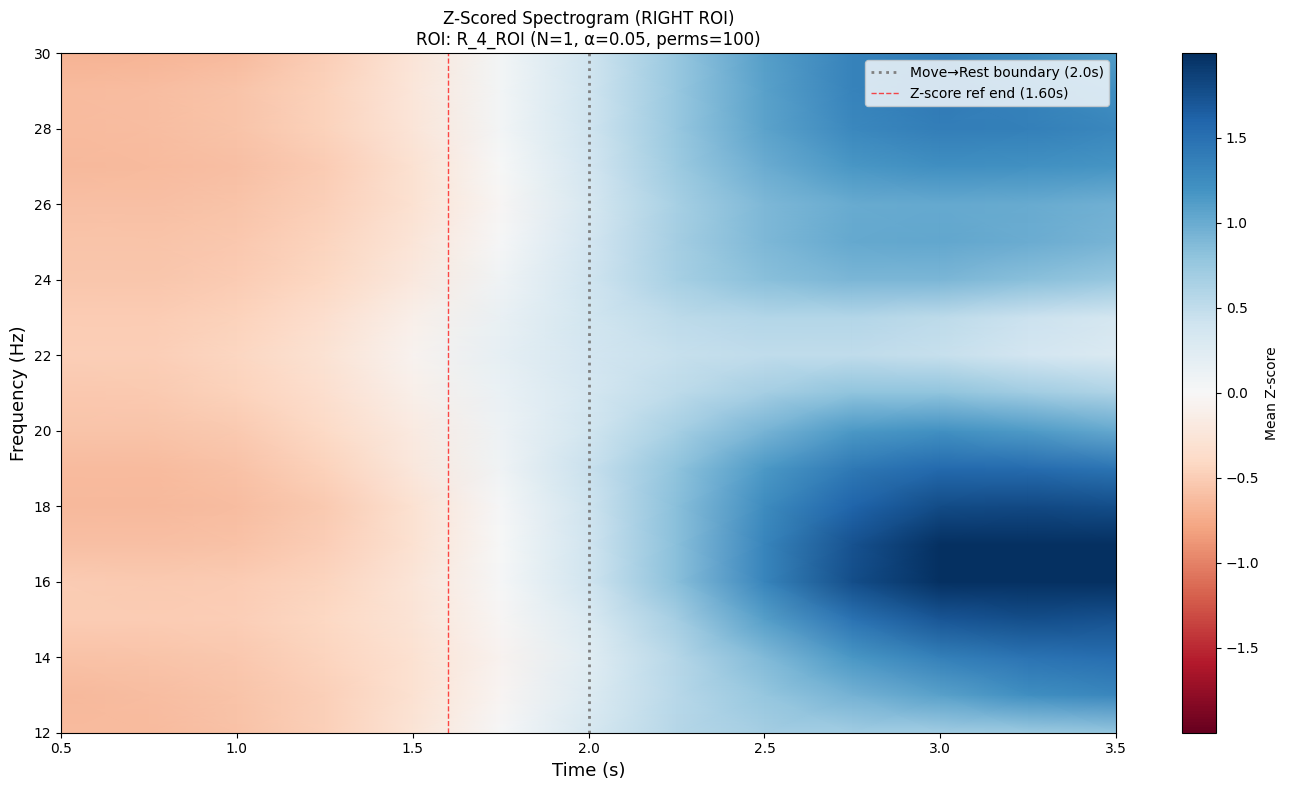

In [2]:
print("\n>>> Starting Spectrogram Analysis...")

# 1. Prepare Signals using the 2D ROI epochs
subjects_data = []
sfreq = fs 

try:
    # The function returns both the signal AND the exact duration derived from data shape
    concat_sig, epoch_dur = ls.prepare_roi_signal_from_2d(move_roi_epochs, rest_roi_epochs, sfreq)
    
    print(f"Detected Epoch Duration: {epoch_dur} seconds")
    
    # Compute Spectrogram
    f, t, sxx_z = ls.compute_zscored_spectrogram(
        concat_sig, sfreq, f_min=12.0, f_max=30.0, baseline_fraction=0.8
    )
    
    subjects_data.append(sxx_z)
    print(f"Processed {SUBJECT_ID}: Spectrogram shape {sxx_z.shape}")
    
except Exception as e:
    print(f"Error processing {SUBJECT_ID}: {e}")
    import traceback
    traceback.print_exc()

# 2. Plot and Test
if subjects_data:
    ls.plot_and_test_group_spectrograms(
        spectrograms_list=subjects_data,
        f=f,
        t=t,
        roi_name=TARGET_ROI,
        hemisphere="right", 
        epoch_dur_sec=epoch_dur, 
        baseline_fraction=0.8,
        n_permutations=100 
    )
else:
    print("No data available for plotting.")